# Nike historical financial analysis

**FY2022-FY2026 | USD millions unless noted**

This independent portfolio analysis evaluates Nike's historical financial performance using reproducible data derived from official SEC filings. It is historical analysis, not an investment recommendation.

## Executive summary

- Revenue reached $51,362 million in FY2024 before declining $4,964 million, or 9.7%, to $46,398 million in FY2026. That left FY2026 revenue $312 million, or 0.7%, below FY2022, corresponding to a -0.2% four-interval CAGR.
- Gross margin decreased from 46.0% to 42.9%, down 3.1 percentage points. Derived operating margin decreased from 14.3% to 8.2%, down 6.1 points, and net margin decreased from 12.9% to 6.7%, down 6.2 points. Over the same period, SG&A increased from 31.7% to 34.7% of revenue, up 3.0 points.
- Free cash flow declined $4,433 million, or 67.0%, from its $6,617 million FY2024 peak to $2,184 million in FY2026. FY2026 FCF margin was 4.7%, and operating cash flow equaled 0.92x net income.
- Cash plus short-term investments decreased from $12,997 million to $9,027 million, the current ratio moved from 2.63x to 1.96x, and net working capital decreased from $17,483 million to $12,056 million. FY2026 receivables grew 25.7% while revenue grew 0.2%; the receivables-days proxy increased from 36.0 to 41.9 days.
- Interest-bearing debt decreased from $9,430 million to $7,942 million, while the net-cash buffer narrowed from $3,567 million to $1,085 million. FY2026 operating lease liabilities of $3,091 million remain separate from debt.

## Data, provenance, and conventions

The analysis uses only the committed [processed historical dataset](../data/processed/nike_financials.csv). Individual facts and calculation lineage are available in the [source manifest](../data/metadata/source_manifest.csv), and Phase 2 controls are summarized in the [validation report](../data/metadata/validation_summary.csv). See the full [methodology](../docs/methodology.md) and [limitations](../docs/limitations.md).

Important conventions:

- `derived_operating_income` equals gross profit less total SG&A. Nike does not report this consolidated subtotal, and it is not segment EBIT.
- Depreciation and amortization uses `Depreciation` for FY2022 and `DepreciationDepletionAndAmortization` for FY2023-FY2026; the source tag did not remain constant.
- Interest-bearing debt includes notes payable or short-term borrowings, current long-term debt, and noncurrent long-term debt. FY2026 short-term borrowings are a filing-supported documented zero.
- Operating lease liabilities remain separate from interest-bearing debt.
- Capital expenditures are shown as a positive investment amount, and free cash flow equals operating cash flow less capital expenditures.
- Cash conversion is a ratio: 1.12 means 1.12x, not 1.12%.
- Efficiency days use a consistent 365-day analytical convention. FY2022 is unavailable because FY2021 opening receivables and inventory are not in the committed dataset.

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

from nike_financial_analysis.analysis import (
    DEFAULT_INPUT,
    build_analysis,
    build_kpi_rows,
    build_presentation_table,
    find_repository_root,
    load_historical_data,
    verify_phase2_hashes,
)

repository_root = find_repository_root(Path.cwd())
phase2_hashes = verify_phase2_hashes(repository_root)
historical_data = load_historical_data(repository_root / DEFAULT_INPUT)
historical_analysis = build_analysis(historical_data)
kpi_rows = build_kpi_rows(historical_analysis)

def show_table(metrics):
    table = build_presentation_table(kpi_rows, metrics)
    display(table.set_index("Metric"))

### Input validation gate

This notebook stops before analysis if the protected Phase 2 files change, expected fiscal periods are missing, statuses are unsupported, or validated inputs lack numeric values.

In [2]:
pd.DataFrame(
    [
        {"Check": "Protected Phase 2 files", "Result": f"{len(phase2_hashes)} hashes verified"},
        {"Check": "Historical periods", "Result": "FY2022-FY2026 present and chronological"},
        {"Check": "Network dependency", "Result": "None"},
    ]
).set_index("Check")

,Result
Check,
Protected Phase 2 files,3 hashes verified
Historical periods,FY2022-FY2026 present and chronological
Network dependency,None


## Revenue and growth

Revenue reached $51,362 million in FY2024 before declining $4,964 million, or 9.7%, to $46,398 million in FY2026. That left FY2026 revenue 0.7% below FY2022, corresponding to a -0.2% four-interval CAGR.

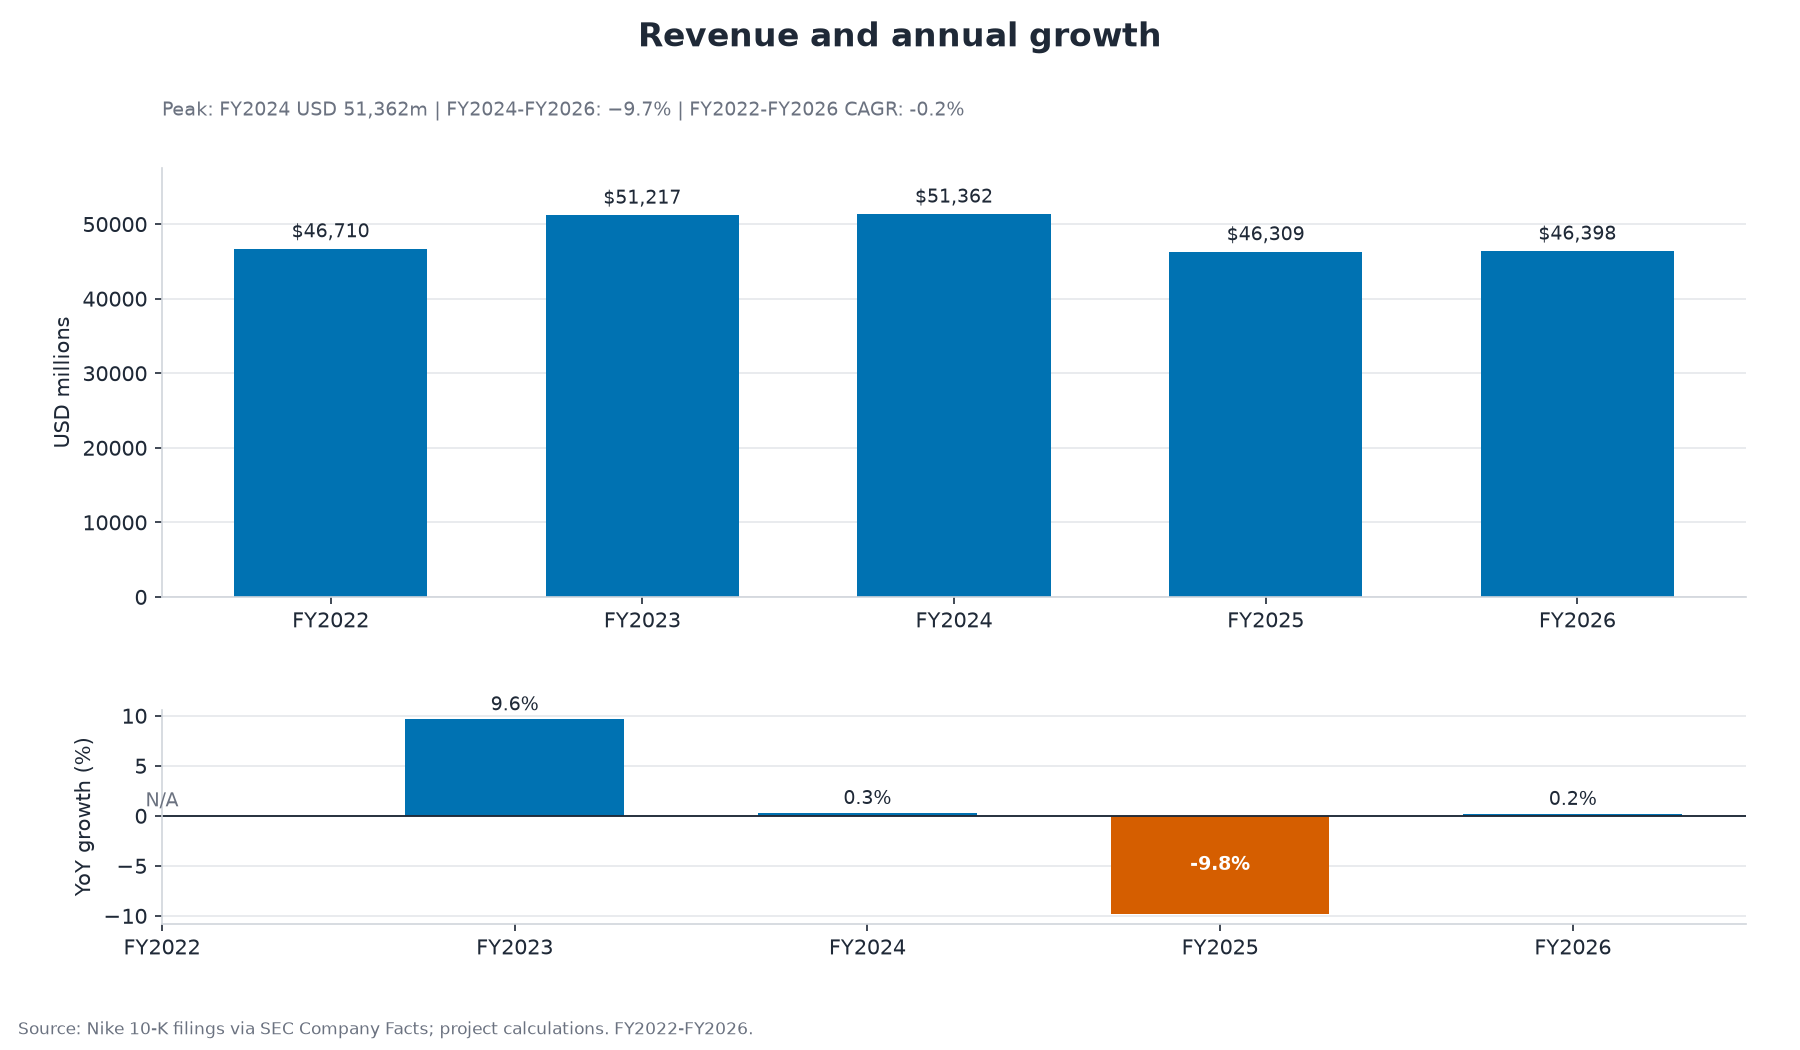

,FY2022,FY2023,FY2024,FY2025,FY2026
Metric,,,,,
Revenue,"$46,710","$51,217","$51,362","$46,309","$46,398"
Revenue growth,N/A,9.6%,0.3%,-9.8%,0.2%
Revenue CAGR,N/A,N/A,N/A,N/A,-0.2%


In [3]:
display(Image(filename=str(repository_root / "outputs/charts/01_revenue_and_growth.png"), embed=True))
show_table(["revenue", "revenue_growth", "revenue_cagr_five_observations"])

## Profitability

From FY2022 to FY2026, gross margin decreased 3.1 percentage points to 42.9%, derived operating margin decreased 6.1 points to 8.2%, and net margin decreased 6.2 points to 6.7%. Over the same period, SG&A increased 3.0 points to 34.7% of revenue. Derived operating income is a project calculation, not a Nike-reported consolidated subtotal or segment EBIT.

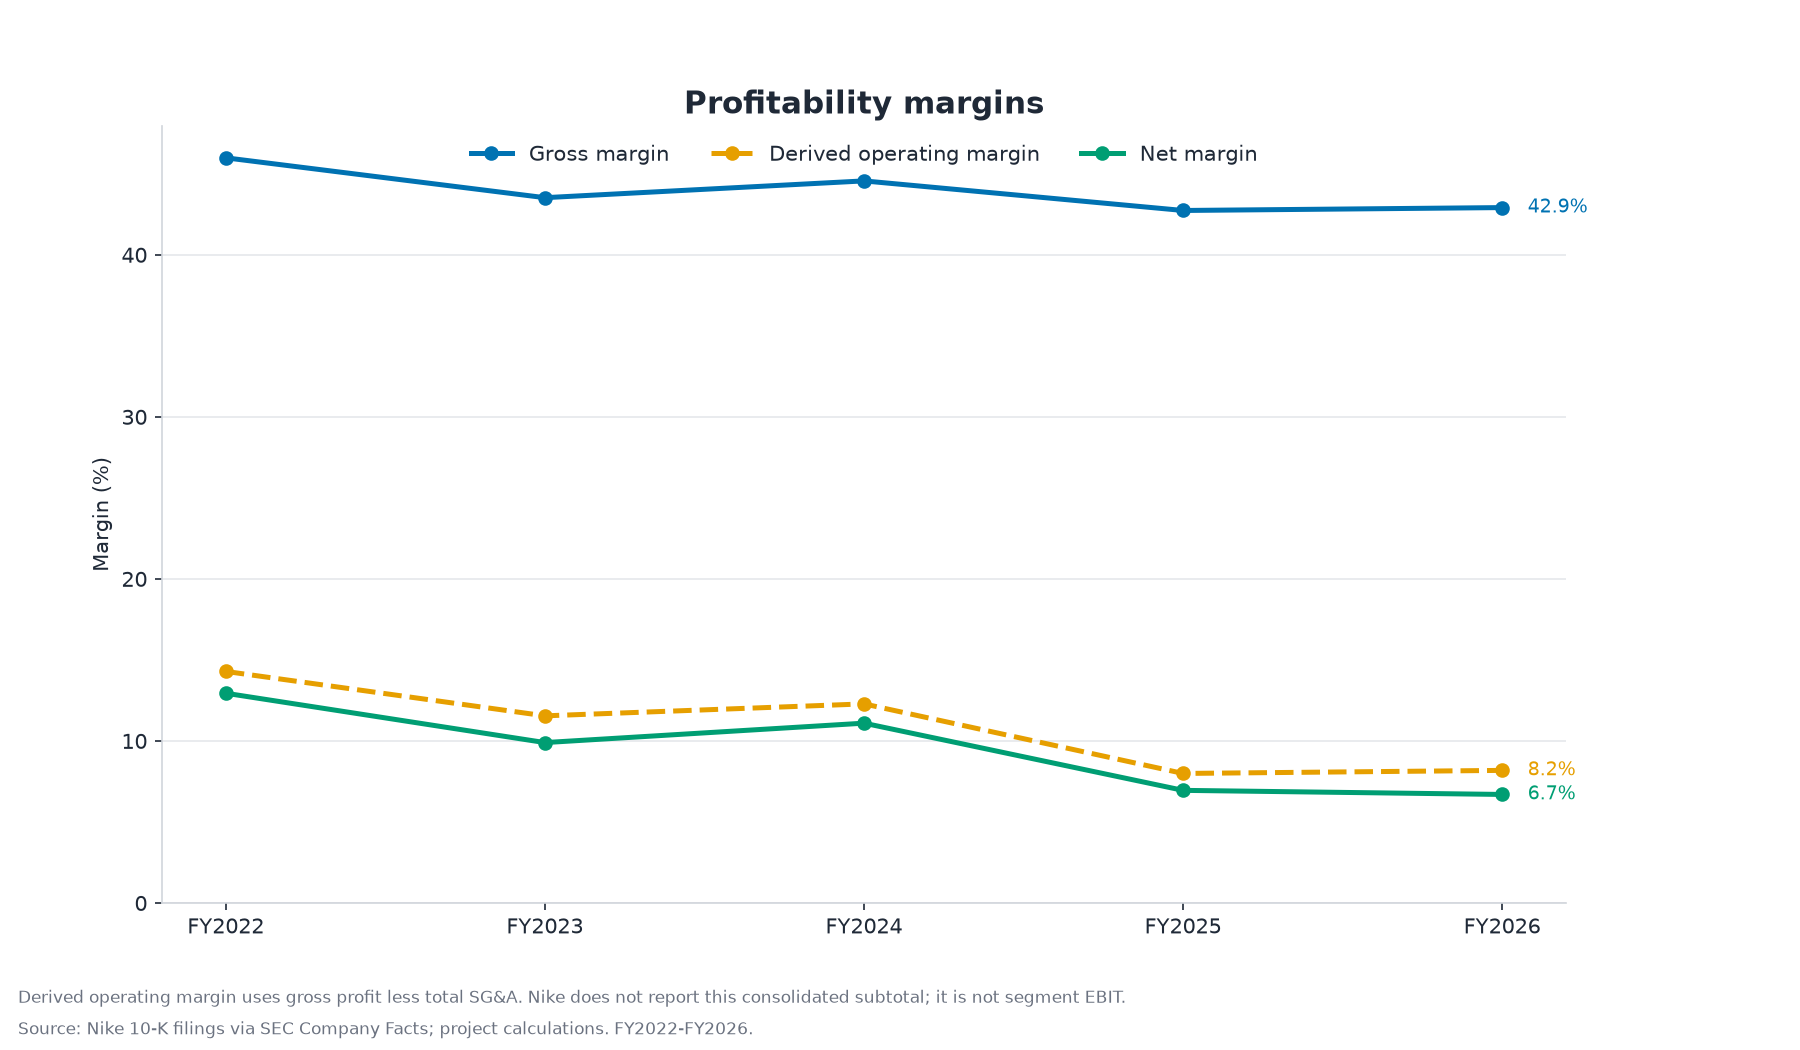

,FY2022,FY2023,FY2024,FY2025,FY2026
Metric,,,,,
Gross margin,46.0%,43.5%,44.6%,42.7%,42.9%
SG&A as a percentage of revenue,31.7%,32.0%,32.3%,34.7%,34.7%
Derived operating margin,14.3%,11.5%,12.3%,8.0%,8.2%
Net margin,12.9%,9.9%,11.1%,7.0%,6.7%


In [4]:
display(Image(filename=str(repository_root / "outputs/charts/02_margin_trends.png"), embed=True))
show_table(["gross_margin", "sga_as_percent_of_revenue", "operating_margin", "net_margin"])

## Cash generation

Free cash flow declined $4,433 million, or 67.0%, from its $6,617 million FY2024 peak to $2,184 million in FY2026. FY2026 FCF margin was 4.7%, and operating cash flow equaled 0.92x net income, below the 1.0x reference.

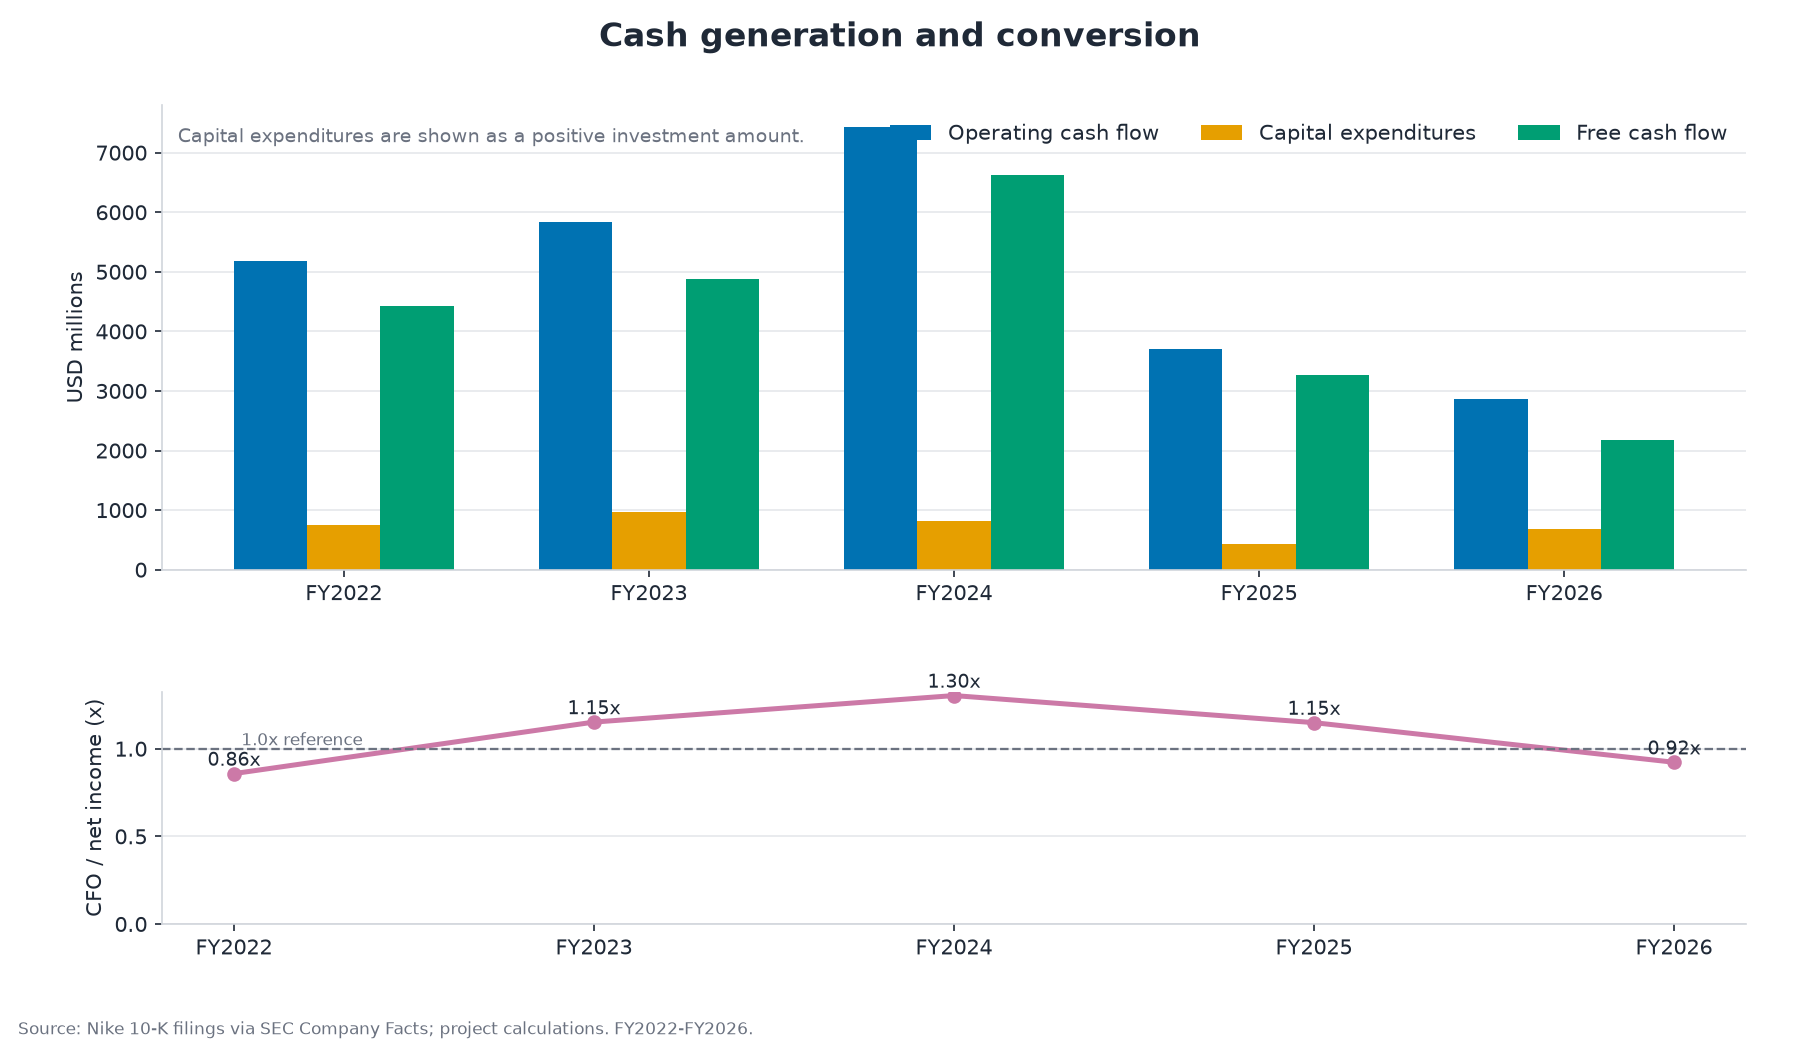

,FY2022,FY2023,FY2024,FY2025,FY2026
Metric,,,,,
Operating cash flow,"$5,188","$5,841","$7,429","$3,698","$2,868"
Capital expenditures,$758,$969,$812,$430,$684
Free cash flow,"$4,430","$4,872","$6,617","$3,268","$2,184"
Free cash flow margin,9.5%,9.5%,12.9%,7.1%,4.7%
Cash conversion,0.86x,1.15x,1.30x,1.15x,0.92x


In [5]:
display(Image(filename=str(repository_root / "outputs/charts/03_cash_generation.png"), embed=True))
show_table(["operating_cash_flow", "capital_expenditures", "free_cash_flow", "free_cash_flow_margin", "cash_conversion"])

## Working capital and liquidity

Cash plus short-term investments decreased from $12,997 million in FY2022 to $9,027 million in FY2026, the current ratio moved from 2.63x to 1.96x, and net working capital decreased from $17,483 million to $12,056 million. FY2026 receivables grew 25.7% while revenue grew 0.2%, and the receivables-days proxy increased from 36.0 days in FY2025 to 41.9 days. This proxy uses total revenue, not separately disclosed credit sales, so it should not be called DSO.

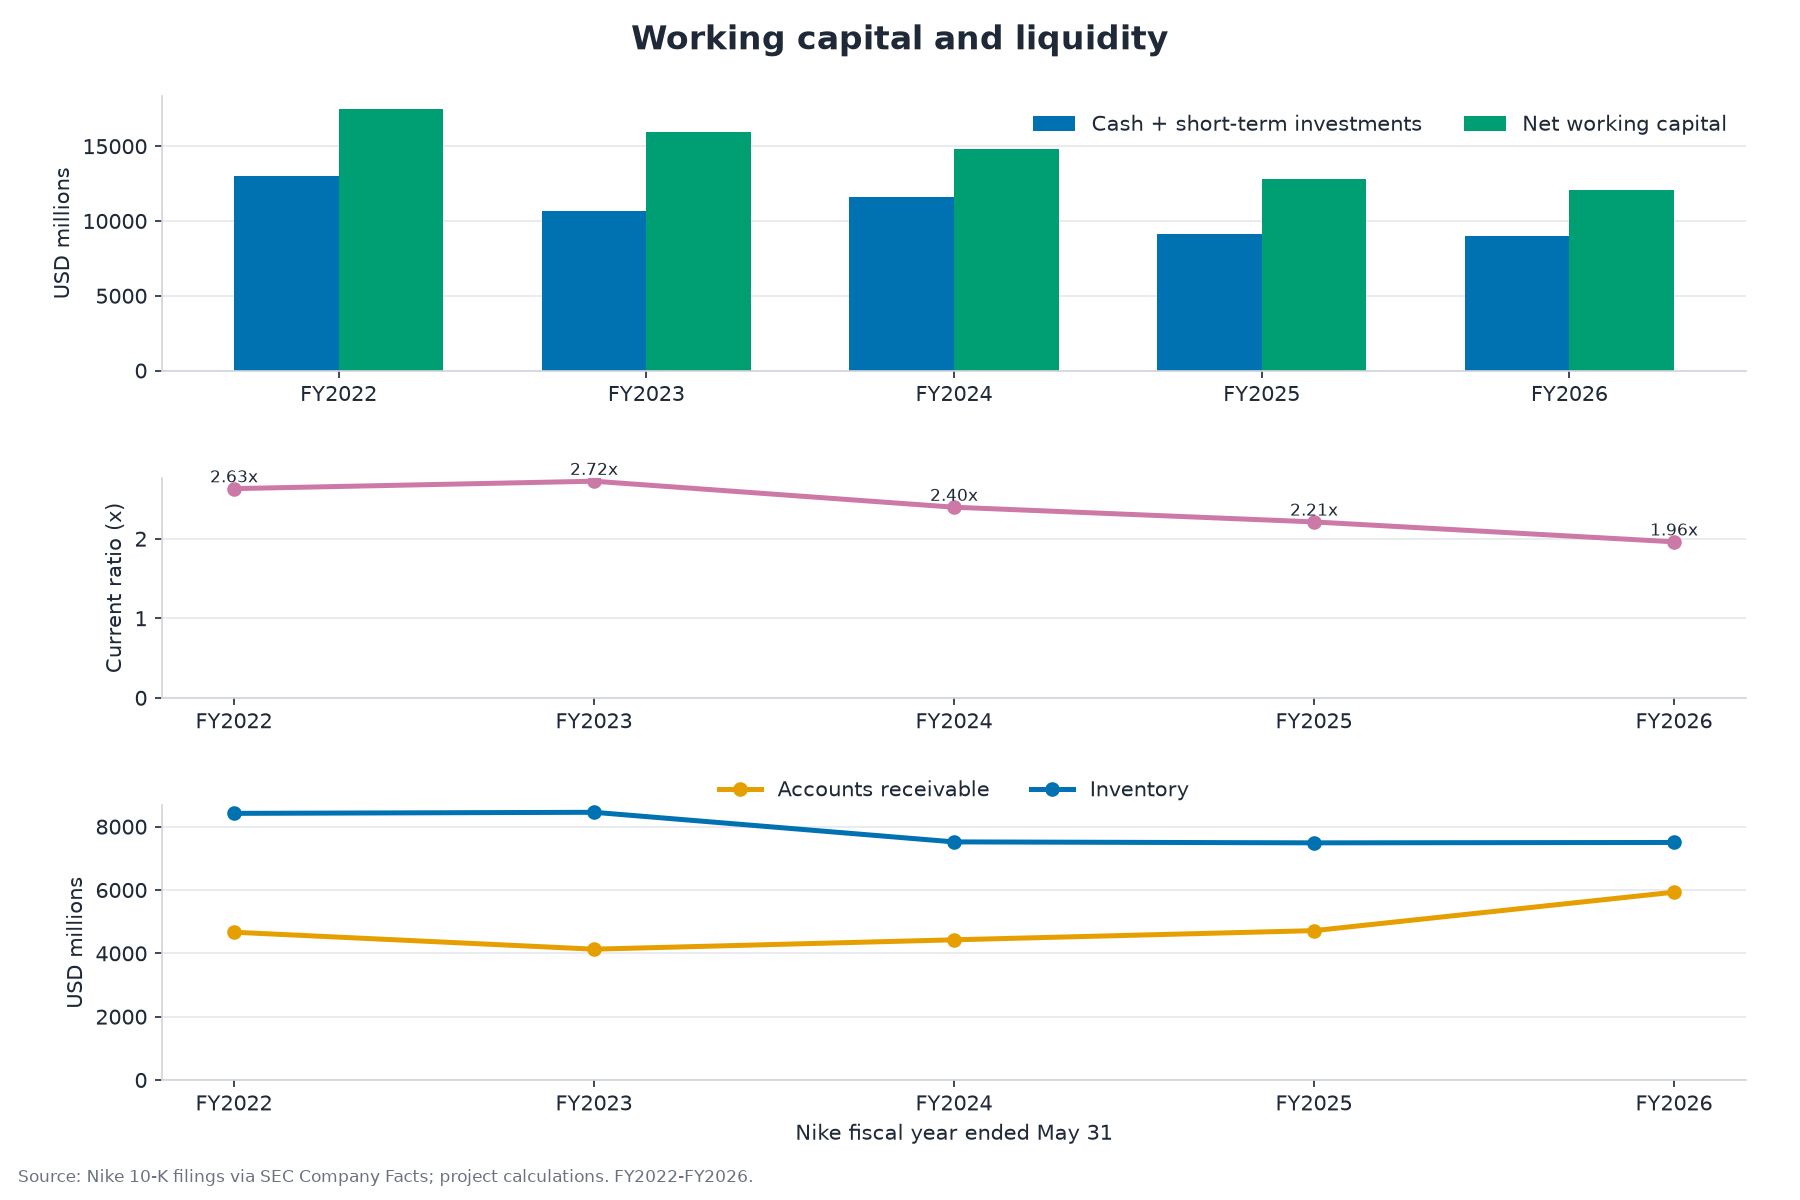

,FY2022,FY2023,FY2024,FY2025,FY2026
Metric,,,,,
Cash plus short-term investments,"$12,997","$10,675","$11,582","$9,151","$9,027"
Current ratio,2.63x,2.72x,2.40x,2.21x,1.96x
Net working capital,"$17,483","$15,946","$14,789","$12,796","$12,056"
Receivables days proxy,N/A,31.3 days,30.4 days,36.0 days,41.9 days
Inventory days,N/A,106.5 days,102.4 days,103.3 days,103.3 days


In [6]:
display(Image(filename=str(repository_root / "outputs/charts/04_working_capital_and_liquidity.png"), embed=True))
show_table(["cash_and_short_term_investments", "current_ratio", "net_working_capital", "receivables_days_proxy", "inventory_days"])

## Capital structure

Interest-bearing debt decreased by $1,488 million, from $9,430 million in FY2022 to $7,942 million in FY2026, while the net-cash buffer narrowed from $3,567 million to $1,085 million. The underlying signed net-debt values remain negative because cash and short-term investments exceeded interest-bearing debt. FY2026 operating lease liabilities of $3,091 million remain separate.

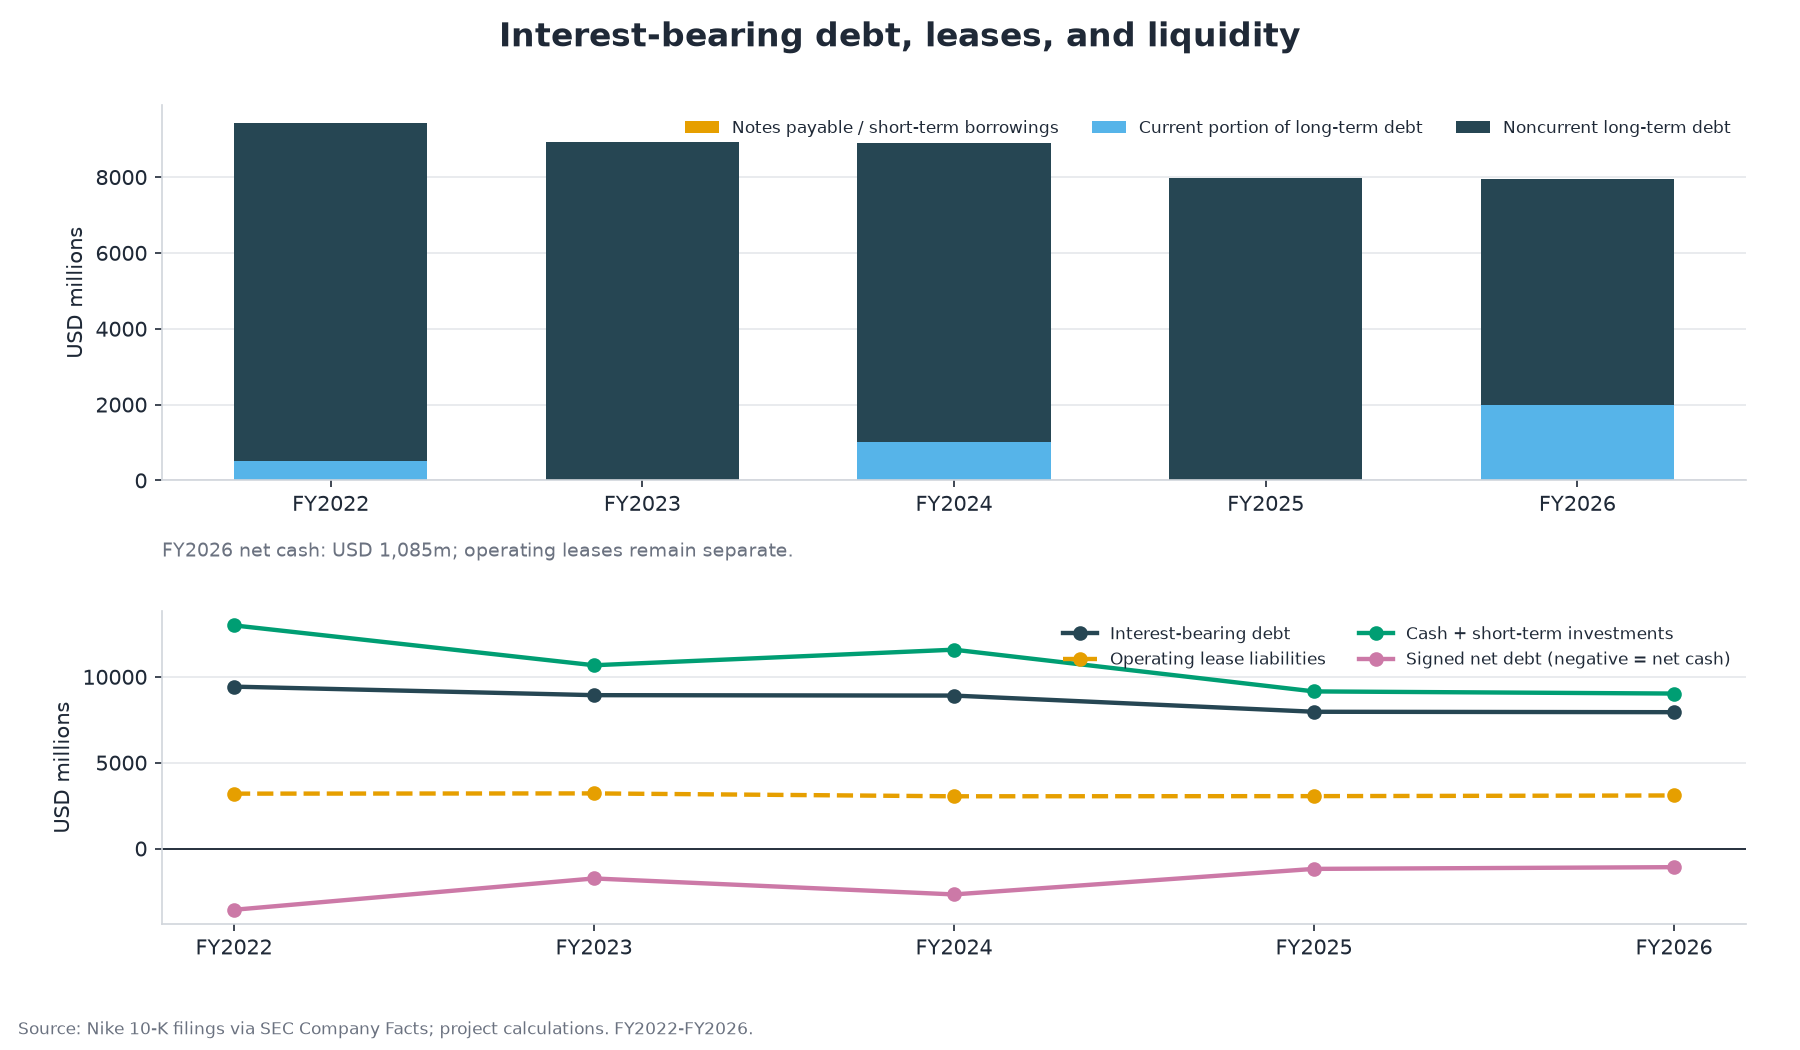

,FY2022,FY2023,FY2024,FY2025,FY2026
Metric,,,,,
Total interest-bearing debt,"$9,430","$8,933","$8,909","$7,966","$7,942"
Total operating lease liabilities,"$3,197","$3,211","$3,043","$3,052","$3,091"
Cash plus short-term investments,"$12,997","$10,675","$11,582","$9,151","$9,027"
Net debt after cash and short-term investments,"-$3,567","-$1,742","-$2,673","-$1,185","-$1,085"


In [7]:
display(Image(filename=str(repository_root / "outputs/charts/05_capital_structure.png"), embed=True))
show_table(["total_interest_bearing_debt", "total_operating_lease_liabilities", "cash_and_short_term_investments", "net_debt_after_cash_and_short_term_investments"])

## Per-share performance

Diluted EPS decreased from $3.75 in FY2022 to $2.10 in FY2026. Diluted weighted-average shares decreased from 1,610.8 million to 1,481.0 million over the same period. The subsection remains tabular because a separate chart would add limited information to the five-figure presentation.

In [8]:
show_table(["diluted_eps", "diluted_eps_growth", "diluted_weighted_average_shares"])

,FY2022,FY2023,FY2024,FY2025,FY2026
Metric,,,,,
Diluted EPS,$3.75,$3.23,$3.73,$2.16,$2.10
Diluted EPS growth,N/A,-13.9%,15.5%,-42.1%,-2.8%
Diluted weighted-average shares,"1,610.8","1,569.8","1,529.7","1,487.6","1,481.0"


## Findings and interpretation boundary

The computed results support conclusions about the direction and size of Nike's historical revenue, margin, cash-flow, liquidity, working-capital, and capital-structure changes. They do not establish why those changes occurred. Any causal explanation would require specific supporting disclosure from Nike's filings and should remain separate from the calculations.

The concise written findings are maintained in [docs/historical_findings.md](../docs/historical_findings.md).

## Limitations

This analysis contains five annual observations and cannot show quarterly seasonality or establish a long-run cycle. Derived operating income is not a reported subtotal. The D&A series crosses a documented XBRL tag transition. Receivables days is a total-revenue proxy, FY2022 efficiency days are unavailable, and operating lease liabilities are excluded from signed net debt. See [docs/limitations.md](../docs/limitations.md) for the complete list.

## Reproduction

From the repository root in Windows PowerShell:

```powershell
uv sync --locked --python 3.14.5
uv run nike-historical-analysis
uv run nike-execute-notebook notebooks/01_historical_analysis.ipynb --in-place
```

The historical-analysis and notebook commands use committed local data and make no network requests. SEC retrieval is a separate Phase 2 reproduction step documented in the README.